In [3]:
from pathlib import Path
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

GREEN = "#43A047"
LIGHT_GREEN = "#A5D6A7"
DARK_GREEN = "#1B5E20"

## Configure paths

In [4]:
BASE_DIR = Path.cwd()

CANDIDATE_DATA_FILES = [
    BASE_DIR / "pair_level_gpt41mini_clean_with_text.csv"
]

DATA_PATH = None
for path in CANDIDATE_DATA_FILES:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No data file found. Put your pair-level CSV in the same folder as this notebook, "
        "preferably named pair_level_dataset.csv."
    )

FIG_DIR = BASE_DIR / "figures_pair_level"
TABLE_DIR = BASE_DIR / "tables_pair_level"
MODEL_DIR = BASE_DIR / "models_pair_level"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Using data file:", DATA_PATH)

Using data file: /content/pair_level_gpt41mini_clean_with_text.csv


## Load dataset

In [5]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

required_columns = {"text", "product", "sentiment", "date_utc"}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    print("Warning: missing expected columns:", missing_columns)

# Standardize core fields.
df["text"] = df["text"].astype(str).fillna("")
df["product"] = df["product"].astype(str).fillna("Unknown")
df["sentiment"] = df["sentiment"].astype(str).str.strip()

# Parse dates for temporal analysis. Invalid dates become NaT.
if "date_utc" in df.columns:
    df["date_utc"] = pd.to_datetime(df["date_utc"], errors="coerce", utc=True)

print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()

Rows: 7031
Columns: ['text_id', 'product', 'sentiment', 'date_utc', 'text']


,text_id,product,sentiment,date_utc,text
0,hqrt7lw,vape,positive,2022-01-01 04:45:21+00:00,Blueberry is and pancake are very well balance...
1,hqs1aeh,vape,neutral,2022-01-01 06:10:06+00:00,"The deeper the oil gets into your lungs, the h..."
2,hqs1aeh,oil,neutral,2022-01-01 06:10:06+00:00,"The deeper the oil gets into your lungs, the h..."
3,hqs7u29,oil,neutral,2022-01-01 07:26:39+00:00,thank you for the advice! i have tried the cbd...
4,hqs7u29,flower,neutral,2022-01-01 07:26:39+00:00,thank you for the advice! i have tried the cbd...


In [6]:
dist = df["sentiment"].value_counts(normalize=True)

n_total = 120
counts = (dist * n_total).round().astype(int)
counts.iloc[0] += (n_total - counts.sum())

realistic = (
    df.groupby("sentiment", group_keys=False)
      .apply(lambda x: x.sample(n=counts[x.name], random_state=42))
      .reset_index(drop=True)
)

realistic["sample_type"] = "realistic"
OUT_PATH = Path("manual_validation_realistic_120.csv")

realistic.to_csv(OUT_PATH, index=False)

print("Saved to:", OUT_PATH.resolve())
print("File exists:", OUT_PATH.exists())
print(realistic["sentiment"].value_counts(normalize=True))

Saved to: /content/manual_validation_realistic_120.csv
File exists: True
sentiment
positive    0.541667
negative    0.283333
neutral     0.175000
Name: proportion, dtype: float64


In [7]:
print("Sentiment counts:")
display(df["sentiment"].value_counts())

print("Product counts:")
display(df["product"].value_counts())

print("Product x sentiment counts:")
display(pd.crosstab(df["product"], df["sentiment"]))

Sentiment counts:


,count
sentiment,
positive,3826
negative,1975
neutral,1230


Product counts:


,count
product,
oil,1816
gummies,1812
vape,1609
flower,1575
topical,219


Product x sentiment counts:


sentiment,negative,neutral,positive
product,,,
flower,403,277,895
gummies,584,302,926
oil,410,309,1097
topical,32,45,142
vape,546,297,766


In [8]:
product_sentiment_counts = (
    df.groupby(["product", "sentiment"])
      .size()
      .reset_index(name="count")
)

product_sentiment_props = product_sentiment_counts.copy()
product_sentiment_props["proportion"] = (
    product_sentiment_props["count"] /
    product_sentiment_props.groupby("product")["count"].transform("sum")
)

product_sentiment_counts.to_csv(TABLE_DIR / "product_sentiment_counts.csv", index=False)
product_sentiment_props.to_csv(TABLE_DIR / "product_sentiment_proportions.csv", index=False)

display(product_sentiment_counts)
display(product_sentiment_props)

,product,sentiment,count
0,flower,negative,403
1,flower,neutral,277
2,flower,positive,895
3,gummies,negative,584
4,gummies,neutral,302
5,gummies,positive,926
6,oil,negative,410
7,oil,neutral,309
8,oil,positive,1097
9,topical,negative,32


,product,sentiment,count,proportion
0,flower,negative,403,0.255873
1,flower,neutral,277,0.175873
2,flower,positive,895,0.568254
3,gummies,negative,584,0.322296
4,gummies,neutral,302,0.166667
5,gummies,positive,926,0.511038
6,oil,negative,410,0.225771
7,oil,neutral,309,0.170154
8,oil,positive,1097,0.604075
9,topical,negative,32,0.146119


## GPT4-Human Comparison

In [9]:
df_human = pd.read_csv(Path("manual_validation_realistic_120_human.csv"))
df_human.columns = [c.strip() for c in df_human.columns]
df_human.head()

,text_id,product,sentiment,date_utc,text,sample_type,human
0,ll3j1oi,gummies,negative,2024-09-02 04:10:48+00:00,When are you people going to understand that a...,realistic,negative
1,lg0xuan,flower,negative,2024-08-01 19:38:03+00:00,"If you wanna do your lungs a favor, use edible...",realistic,negative
2,j4mz4m1,flower,negative,2023-01-16 21:23:29+00:00,Because that is how fact works. It doesn't cha...,realistic,negative
3,iees67h,oil,negative,2022-07-01 03:58:13+00:00,"The one with discoloring looks terrible , it’s...",realistic,negative
4,lkxcxtw,oil,negative,2024-09-01 01:57:20+00:00,"You don’t need much. Olive oil would do it, ev...",realistic,negative


GPT Sentiment Accuracy: 0.508
Cohen's Kappa: 0.301


,precision,recall,f1-score,support
positive,0.723077,0.886792,0.796610,53.000000
neutral,0.666667,0.358974,0.466667,39.000000
negative,0.705882,0.857143,0.774194,28.000000
accuracy,0.708333,0.708333,0.708333,0.708333
macro avg,0.698542,0.700970,0.679157,120.000000
weighted avg,0.700732,0.708333,0.684148,120.000000


,GPT: positive,GPT: neutral,GPT: negative
Human: positive,47,5,1
Human: neutral,16,14,9
Human: negative,2,2,24


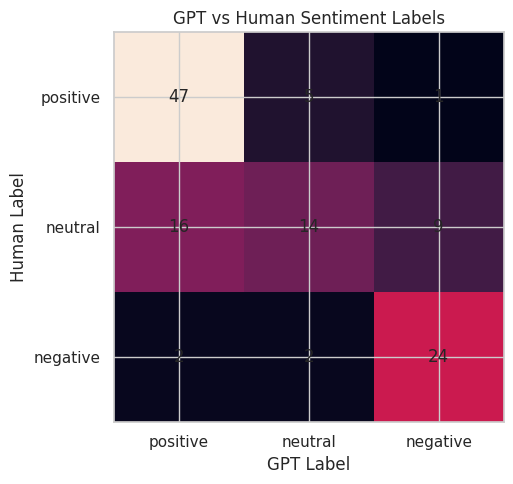

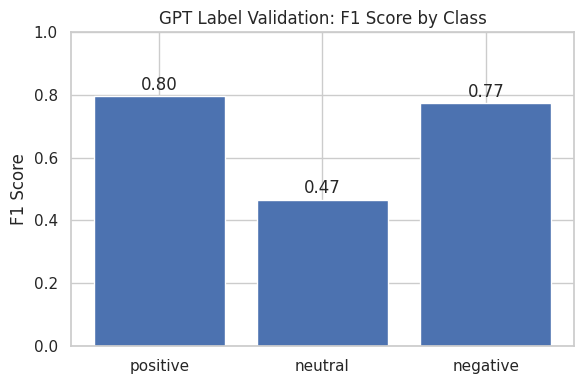

Number of disagreements: 35
Disagreement rate: 0.292


,text_id,product,sentiment,human,text
5,izwbqsh,oil,negative,neutral,You already mentioned edibles. Tinctures are a...
10,iunu6xf,vape,negative,neutral,As someone who used to be on & around opiates ...
13,ioryhqe,vape,negative,positive,Vaping carts in an illegal state is very risky...
16,iv3kmhn,flower,negative,neutral,More flavor because the trichromes hadn't been...
17,jfev7nw,gummies,negative,neutral,It was a pack of gummies that was 500mg each l...
18,iqln1fj,vape,negative,neutral,Can I offer a suggestion? I know this post is ...
20,jwm6go4,oil,negative,neutral,When I was a youngin I took an RSO tincture an...
21,iovrd82,flower,negative,neutral,so i get what you're implying and its a fair q...
23,iuuv157,gummies,negative,neutral,I took an 11 month tolerance break after smoki...
28,ij7y1zb,vape,negative,neutral,If you’re expecting a high like thc then you w...


,Metric,Value
0,Evaluated rows,120.000
1,GPT sentiment accuracy,0.508
2,Cohen's kappa,0.301
3,Disagreement count,35.000
4,Disagreement rate,0.292


Macro F1 (GPT vs Human): 0.679


In [10]:


from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)


acc = accuracy_score(df_human["human"], df_human["sentiment"])
kappa = cohen_kappa_score(df_human["human"], df_human["sentiment"])

print(f"GPT Sentiment Accuracy: {acc:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")

labels = ["positive", "neutral", "negative"]
df_human["human"] = df_human["human"].str.strip().str.lower()
df_human["sentiment"] = df_human["sentiment"].str.strip().str.lower()

report = classification_report(
    df_human["human"],
    df_human["sentiment"],
    labels=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)
report_df.to_csv("gpt_human_validation_classification_report.csv")


cm = confusion_matrix(
    df_human["human"],
    df_human["sentiment"],
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Human: {x}" for x in labels],
    columns=[f"GPT: {x}" for x in labels]
)

display(cm_df)
cm_df.to_csv("gpt_human_validation_confusion_matrix.csv")



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("GPT Label")
ax.set_ylabel("Human Label")
ax.set_title("GPT vs Human Sentiment Labels")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

fig.tight_layout()
plt.savefig("gpt_human_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

class_report = report_df.loc[labels]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_report.index, class_report["f1-score"])

ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score")
ax.set_title("GPT Label Validation: F1 Score by Class")

for i, value in enumerate(class_report["f1-score"]):
    ax.text(i, value + 0.02, f"{value:.2f}", ha="center")

fig.tight_layout()
plt.savefig("gpt_human_f1_by_class.png", dpi=300, bbox_inches="tight")
plt.show()



disagreements = df_human[df_human["human"] != df_human["sentiment"]].copy()

print("Number of disagreements:", len(disagreements))
print("Disagreement rate:", round(len(disagreements) / len(df_human), 3))

display(
    disagreements[
        ["text_id", "product", "sentiment", "human", "text"]
    ].head(20)
)

disagreements.to_csv("gpt_human_label_disagreements.csv", index=False)


summary_df = pd.DataFrame({
    "Metric": [
        "Evaluated rows",
        "GPT sentiment accuracy",
        "Cohen's kappa",
        "Disagreement count",
        "Disagreement rate"
    ],
    "Value": [
        len(df_human),
        round(acc, 3),
        round(kappa, 3),
        len(disagreements),
        round(len(disagreements) / len(df_human), 3)
    ]
})

display(summary_df)

summary_df.to_csv("gpt_human_validation_summary.csv", index=False)
macro_f1 = report_df.loc["macro avg", "f1-score"]
print(f"Macro F1 (GPT vs Human): {macro_f1:.3f}")

## 5. Label encoding and train/test splits

In [11]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])
class_names = list(label_encoder.classes_)
n_classes = len(class_names)

print("Class mapping:", dict(zip(class_names, range(n_classes))))

Class mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [12]:
def make_random_split(df, test_size=0.20):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=df["label"],
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

def make_temporal_split(df, train_frac=0.80):
    dated = df.dropna(subset=["date_utc"]).sort_values("date_utc").reset_index(drop=True)
    if len(dated) < 50:
        raise ValueError("Not enough dated rows for a temporal split.")
    cutoff = int(len(dated) * train_frac)
    train_df = dated.iloc[:cutoff].copy()
    test_df = dated.iloc[cutoff:].copy()
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

USE_TEMPORAL_SPLIT = "date_utc" in df.columns and df["date_utc"].notna().sum() >= 50

df["input_product_only"] = "Product: " + df["product"].astype(str)
df["input_product_conditioned"] = (
    "Product: " + df["product"].astype(str) +
    ". Text: " + df["text"].astype(str)
)

df["model_input"] = df["input_product_conditioned"]

representation_columns = {
    "Product-only TF-IDF": "input_product_only",
    "Product-conditioned TF-IDF": "input_product_conditioned",
}

splits = {}
random_train, random_test = make_random_split(df)
splits["random"] = (random_train, random_test)

if USE_TEMPORAL_SPLIT:
    temporal_train, temporal_test = make_temporal_split(df)
    splits["temporal"] = (temporal_train, temporal_test)

for split_name, (train_df, test_df) in splits.items():
    print("\nSplit:", split_name)
    print("Train rows:", len(train_df), "Test rows:", len(test_df))
    if split_name == "temporal":
        print("Train dates:", train_df["date_utc"].min(), "to", train_df["date_utc"].max())
        print("Test dates:", test_df["date_utc"].min(), "to", test_df["date_utc"].max())
    print("Train sentiment distribution:")
    print(train_df["sentiment"].value_counts(normalize=True))
    print("Test sentiment distribution:")
    print(test_df["sentiment"].value_counts(normalize=True))


Split: random
Train rows: 5624 Test rows: 1407
Train sentiment distribution:
sentiment
positive    0.544097
negative    0.280939
neutral     0.174964
Name: proportion, dtype: float64
Test sentiment distribution:
sentiment
positive    0.544421
negative    0.280739
neutral     0.174840
Name: proportion, dtype: float64

Split: temporal
Train rows: 5624 Test rows: 1407
Train dates: 2022-01-01 04:45:21+00:00 to 2024-06-01 05:22:10+00:00
Test dates: 2024-06-01 05:51:43+00:00 to 2024-12-27 17:33:45+00:00
Train sentiment distribution:
sentiment
positive    0.535028
negative    0.285740
neutral     0.179232
Name: proportion, dtype: float64
Test sentiment distribution:
sentiment
positive    0.580668
negative    0.261549
neutral     0.157783
Name: proportion, dtype: float64


## Helper Function

In [13]:
def multiclass_ece(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    ece = 0.0
    bin_edges = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > left) & (confidences <= right)
        if mask.any():
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += mask.mean() * abs(bin_acc - bin_conf)

    return ece

def evaluate_model_outputs(y_true, y_pred, y_prob=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    w_precision, w_recall, w_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "Weighted Precision": w_precision,
        "Weighted Recall": w_recall,
        "Weighted F1": w_f1,
    }

    if y_prob is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
            out["Macro AUROC"] = roc_auc_score(
                y_true_bin, y_prob, average="macro", multi_class="ovr"
            )
        except Exception:
            out["Macro AUROC"] = np.nan
        out["ECE"] = multiclass_ece(y_true, y_prob)

    return out

def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()

## Classical TF-IDF models

In [14]:
def make_tfidf_pipeline(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.95,
            max_features=50000,
            sublinear_tf=True
        )),
        ("clf", clf)
    ])

def train_classical_models_for_split(train_df, test_df, split_name, representation_name, input_column):
    X_train = train_df[input_column].values
    X_test = test_df[input_column].values
    y_train = train_df["label"].values
    y_test = test_df["label"].values

    models = {
        "Naive Bayes": ComplementNB(),
        "Logistic Regression": LogisticRegression(max_iter=3000, multi_class="ovr", class_weight="balanced", solver="liblinear"),
        "LinearSVC": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, multi_class="ovr"),
        "Decision Tree": DecisionTreeClassifier(max_depth=30, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    }

    rows = []
    outputs = {}

    for name, clf in models.items():
        print(f"Training {name} | {representation_name} | {split_name} split...")
        pipe = make_tfidf_pipeline(clf)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        y_prob = None
        if hasattr(pipe, "predict_proba"):
            try:
                y_prob = pipe.predict_proba(X_test)
            except Exception:
                y_prob = None

        metrics = evaluate_model_outputs(y_test, y_pred, y_prob)
        metrics.update({
            "Model": name,
            "Representation": representation_name,
            "Split": split_name,
        })
        rows.append(metrics)

        outputs[(representation_name, name)] = {
            "pipeline": pipe,
            "y_true": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "test_df": test_df.copy(),
            "input_column": input_column,
        }

    return pd.DataFrame(rows), outputs

all_classical_results = []
all_classical_outputs = {}

for split_name, (train_df, test_df) in splits.items():
    all_classical_outputs[split_name] = {}
    for representation_name, input_column in representation_columns.items():
        results_df, outputs = train_classical_models_for_split(
            train_df, test_df, split_name, representation_name, input_column
        )
        all_classical_results.append(results_df)
        all_classical_outputs[split_name].update(outputs)

classical_results_df = pd.concat(all_classical_results, ignore_index=True)
classical_results_df = classical_results_df.sort_values(["Split", "Representation", "Macro F1"], ascending=[True, True, False])
classical_results_df.to_csv(TABLE_DIR / "classical_ablation_results.csv", index=False)

display(classical_results_df)

Training Naive Bayes | Product-only TF-IDF | random split...
Training Logistic Regression | Product-only TF-IDF | random split...
Training LinearSVC | Product-only TF-IDF | random split...
Training Decision Tree | Product-only TF-IDF | random split...
Training Random Forest | Product-only TF-IDF | random split...
Training Naive Bayes | Product-conditioned TF-IDF | random split...
Training Logistic Regression | Product-conditioned TF-IDF | random split...
Training LinearSVC | Product-conditioned TF-IDF | random split...
Training Decision Tree | Product-conditioned TF-IDF | random split...
Training Random Forest | Product-conditioned TF-IDF | random split...
Training Naive Bayes | Product-only TF-IDF | temporal split...
Training Logistic Regression | Product-only TF-IDF | temporal split...
Training LinearSVC | Product-only TF-IDF | temporal split...
Training Decision Tree | Product-only TF-IDF | temporal split...
Training Random Forest | Product-only TF-IDF | temporal split...
Training N

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
6,0.573561,0.520513,0.484742,0.494663,0.557856,0.573561,0.559991,0.695315,0.077131,Logistic Regression,Product-conditioned TF-IDF,random
7,0.535181,0.484817,0.485262,0.485036,0.535161,0.535181,0.535169,NaN,NaN,LinearSVC,Product-conditioned TF-IDF,random
9,0.552239,0.505469,0.431117,0.438041,0.527145,0.552239,0.516929,0.647268,0.079458,Random Forest,Product-conditioned TF-IDF,random
8,0.501777,0.415124,0.387446,0.387370,0.464427,0.501777,0.471114,0.579686,0.320330,Decision Tree,Product-conditioned TF-IDF,random
5,0.560768,0.564037,0.379723,0.344256,0.549808,0.560768,0.462175,0.666494,0.052338,Naive Bayes,Product-conditioned TF-IDF,random
4,0.442075,0.341346,0.365188,0.330410,0.428824,0.442075,0.419388,0.528784,0.083235,Random Forest,Product-only TF-IDF,random
0,0.459844,0.304194,0.371468,0.327111,0.412142,0.459844,0.426832,0.539097,0.084385,Naive Bayes,Product-only TF-IDF,random
1,0.503909,0.290431,0.348175,0.310740,0.391576,0.503909,0.434858,0.535214,0.084706,Logistic Regression,Product-only TF-IDF,random
2,0.503909,0.290431,0.348175,0.310740,0.391576,0.503909,0.434858,NaN,NaN,LinearSVC,Product-only TF-IDF,random
3,0.544421,0.181474,0.333333,0.235005,0.296394,0.544421,0.383825,0.535214,0.001523,Decision Tree,Product-only TF-IDF,random


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
6,0.573561,0.520513,0.484742,0.494663,0.557856,0.573561,0.559991,0.695315,0.077131,Logistic Regression,Product-conditioned TF-IDF,random
4,0.442075,0.341346,0.365188,0.330410,0.428824,0.442075,0.419388,0.528784,0.083235,Random Forest,Product-only TF-IDF,random
17,0.575693,0.456224,0.452887,0.450642,0.549499,0.575693,0.560147,NaN,NaN,LinearSVC,Product-conditioned TF-IDF,temporal
11,0.546553,0.320089,0.374481,0.343410,0.446678,0.546553,0.489926,0.566955,0.137308,Logistic Regression,Product-only TF-IDF,temporal


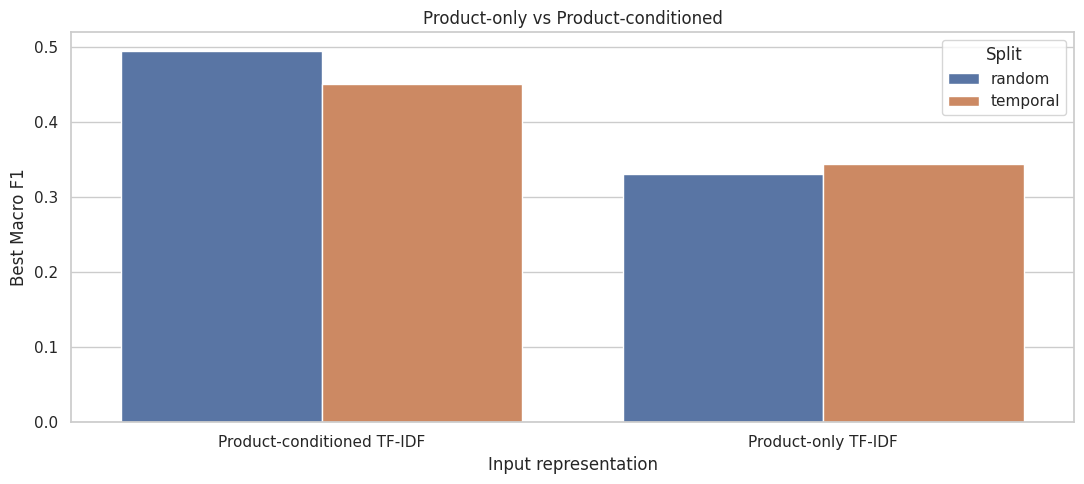

In [15]:
ablation_summary_df = (
    classical_results_df
    .sort_values(["Split", "Representation", "Macro F1"], ascending=[True, True, False])
    .groupby(["Split", "Representation"], as_index=False)
    .head(1)
    .sort_values(["Split", "Macro F1"], ascending=[True, False])
)
ablation_summary_df.to_csv(TABLE_DIR / "ablation_summary_best_by_representation.csv", index=False)
display(ablation_summary_df)

plt.figure(figsize=(11, 5))
sns.barplot(data=ablation_summary_df, x="Representation", y="Macro F1", hue="Split")
plt.title("Product-only vs Product-conditioned")
plt.xlabel("Input representation")
plt.ylabel("Best Macro F1")
plt.xticks(ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_best_macro_f1_by_representation.png", dpi=300)
plt.show()

In [16]:
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from tqdm.auto import tqdm

# Tune the main product-conditioned logistic regression model on the random training split.
tuning_train_df, tuning_test_df = splits["random"]

param_grid = {
    "tfidf__ngram_range": [(1, 2), (1, 3), (1, 4)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "clf__C": [0.5, 1.0, 2.0, 4.0],
}

base_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        stop_words="english",
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        multi_class="ovr",
        solver="liblinear"
    ))
])

X = tuning_train_df["input_product_conditioned"].values
y = tuning_train_df["label"].values

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []

for params in tqdm(list(ParameterGrid(param_grid)), desc="Grid search progress"):
    model = clone(base_pipeline)
    model.set_params(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    results.append({**params, "mean_f1_macro": scores.mean(), "std_f1_macro": scores.std()})

grid_results_df = pd.DataFrame(results).sort_values("mean_f1_macro", ascending=False)
grid_results_df.to_csv(TABLE_DIR / "logistic_regression_grid_search.csv", index=False)
display(grid_results_df.head(10))

best_params = grid_results_df.iloc[0].drop(["mean_f1_macro", "std_f1_macro"]).to_dict()
best_model = clone(base_pipeline).set_params(**best_params)
best_model.fit(tuning_train_df["input_product_conditioned"], tuning_train_df["label"])
y_pred = best_model.predict(tuning_test_df["input_product_conditioned"])

print("Best params:")
print(best_params)
print("\nBest CV macro F1:", grid_results_df.iloc[0]["mean_f1_macro"])
print("\nHeld-out random split results:")
print(classification_report(tuning_test_df["label"], y_pred, target_names=class_names, zero_division=0))

Grid search progress:   0%|          | 0/108 [00:00<?, ?it/s]

,clf__C,tfidf__max_df,tfidf__min_df,tfidf__ngram_range,mean_f1_macro,std_f1_macro
60,2.0,0.90,3,"(1, 2)",0.490683,0.009577
69,2.0,0.95,3,"(1, 2)",0.490683,0.009577
78,2.0,1.00,3,"(1, 2)",0.490541,0.008621
57,2.0,0.90,2,"(1, 2)",0.490392,0.012199
66,2.0,0.95,2,"(1, 2)",0.490392,0.012199
75,2.0,1.00,2,"(1, 2)",0.490040,0.012766
79,2.0,1.00,3,"(1, 3)",0.489297,0.009556
87,4.0,0.90,3,"(1, 2)",0.489036,0.012133
96,4.0,0.95,3,"(1, 2)",0.489036,0.012133
105,4.0,1.00,3,"(1, 2)",0.488747,0.012083


Best params:
{'clf__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}

Best CV macro F1: 0.49068315991160033

Held-out random split results:
              precision    recall  f1-score   support

    negative       0.44      0.42      0.43       395
     neutral       0.44      0.36      0.40       246
    positive       0.65      0.71      0.68       766

    accuracy                           0.57      1407
   macro avg       0.51      0.49      0.50      1407
weighted avg       0.56      0.57      0.56      1407



## 10-fold cross-validation for the best classical model

Running 10-fold CV.


,Model,Representation,Split,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Logistic Regression,Product-conditioned TF-IDF,10-fold CV,0.575452,0.517956,0.504221,0.50961,0.565819,0.575452,0.569457


              precision    recall  f1-score   support

    negative       0.47      0.44      0.45      1975
     neutral       0.43      0.36      0.39      1230
    positive       0.66      0.71      0.69      3826

    accuracy                           0.58      7031
   macro avg       0.52      0.50      0.51      7031
weighted avg       0.57      0.58      0.57      7031



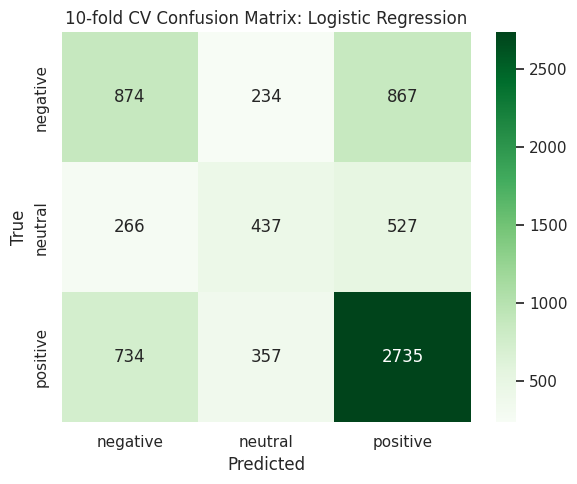

In [17]:
X_all = df["model_input"].values
y_all = df["label"].values

cv_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True
    )),
    ("logistic_regression", LogisticRegression(
        max_iter=3000,
        multi_class="ovr",
        class_weight="balanced",
        solver="liblinear",
        C=2.0
    )),
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running 10-fold CV.")
y_pred_cv = cross_val_predict(cv_model, X_all, y_all, cv=cv, method="predict")

cv_metrics = evaluate_model_outputs(y_all, y_pred_cv, None)

cv_results_df = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Representation": "Product-conditioned TF-IDF",
    "Split": "10-fold CV",
    **cv_metrics,
}])

cv_results_df.to_csv(TABLE_DIR / "classical_10fold_cv_results.csv", index=False)

display(cv_results_df)

print(classification_report(
    y_all,
    y_pred_cv,
    target_names=class_names,
    zero_division=0
))

plot_confusion_matrix(
    y_all,
    y_pred_cv,
    title="10-fold CV Confusion Matrix: Logistic Regression",
    save_path=FIG_DIR / "cv_logistic_regression_confusion_matrix.png",
)

## DistilBERT Model

In [18]:
RUN_BERT = True
BERT_MODEL_NAME = "distilbert-base-uncased"
Roberta_MODEL_NAME = "roberta-base"
Bertweet_MODEL_NAME = "vinai/bertweet-base"
BERT_EPOCHS = 3
BERT_BATCH_SIZE = 16
MAX_LENGTH = 256

Running BERT split: random


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


              precision    recall  f1-score   support

    negative       0.52      0.55      0.53       395
     neutral       0.51      0.22      0.30       246
    positive       0.68      0.79      0.73       766

    accuracy                           0.62      1407
   macro avg       0.57      0.52      0.52      1407
weighted avg       0.61      0.62      0.60      1407



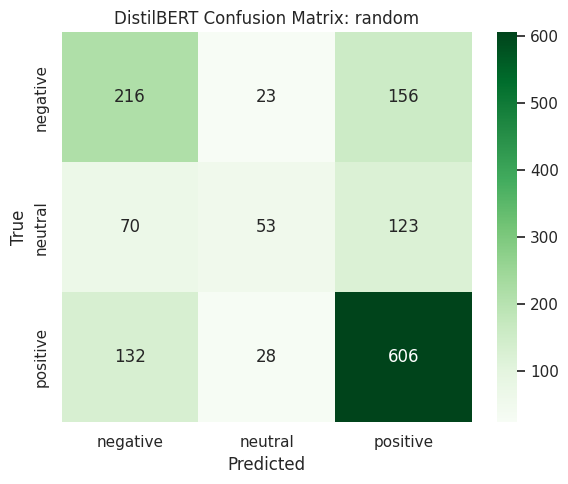

Running BERT split: temporal


Map:   0%|          | 0/5624 [00:00<?, ? examples/s]

Map:   0%|          | 0/1407 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


              precision    recall  f1-score   support

    negative       0.59      0.60      0.59       368
     neutral       0.33      0.18      0.24       222
    positive       0.72      0.81      0.76       817

    accuracy                           0.65      1407
   macro avg       0.55      0.53      0.53      1407
weighted avg       0.63      0.65      0.64      1407



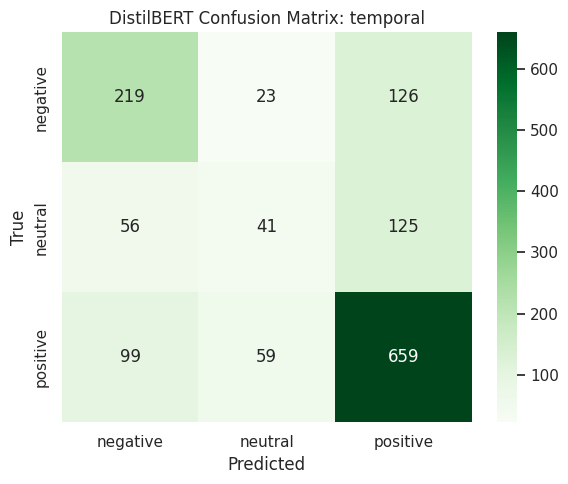

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
0,0.621891,0.570369,0.517802,0.522774,0.606962,0.621891,0.601786,0.744456,0.110992,distilbert-base-uncased,Product-conditioned transformer,random
1,0.653163,0.547690,0.528801,0.530384,0.626253,0.653163,0.635044,0.761817,0.073523,distilbert-base-uncased,Product-conditioned transformer,temporal


In [19]:
if RUN_BERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        TrainingArguments,
        Trainer,
    )

    def run_bert_for_split(train_df, test_df, split_name):
        train_bert = train_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()
        test_bert = test_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()

        train_ds = Dataset.from_pandas(train_bert)
        test_ds = Dataset.from_pandas(test_bert)

        tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

        def tokenize_batch(batch):
            return tokenizer(
                batch["model_input"],
                truncation=True,
                max_length=MAX_LENGTH,
            )

        train_ds = train_ds.map(tokenize_batch, batched=True)
        test_ds = test_ds.map(tokenize_batch, batched=True)

        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        id2label = {i: label for i, label in enumerate(class_names)}
        label2id = {label: i for i, label in enumerate(class_names)}

        model = AutoModelForSequenceClassification.from_pretrained(
            BERT_MODEL_NAME,
            num_labels=n_classes,
            id2label=id2label,
            label2id=label2id,
        )

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            out = evaluate_model_outputs(labels, preds, None)
            return {
                "accuracy": out["Accuracy"],
                "macro_precision": out["Macro Precision"],
                "macro_recall": out["Macro Recall"],
                "macro_f1": out["Macro F1"],
                "weighted_f1": out["Weighted F1"],
            }

        args = TrainingArguments(
            output_dir=str(MODEL_DIR / f"distilbert_{split_name}"),
            learning_rate=2e-5,
            per_device_train_batch_size=BERT_BATCH_SIZE,
            per_device_eval_batch_size=BERT_BATCH_SIZE,
            num_train_epochs=BERT_EPOCHS,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            logging_steps=50,
            report_to="none",
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        pred_output = trainer.predict(test_ds)

        logits = pred_output.predictions
        y_true = pred_output.label_ids
        y_pred = np.argmax(logits, axis=1)

        # Softmax probabilities.
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        y_prob = exp_logits / exp_logits.sum(axis=1, keepdims=True)

        metrics = evaluate_model_outputs(y_true, y_pred, y_prob)
        metrics.update({
            "Model": BERT_MODEL_NAME,
            "Representation": "Product-conditioned transformer",
            "Split": split_name,
        })

        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
        plot_confusion_matrix(
            y_true,
            y_pred,
            title=f"DistilBERT Confusion Matrix: {split_name}",
            save_path=FIG_DIR / f"distilbert_confusion_{split_name}.png",
        )

        pred_df = test_df.copy()
        pred_df["predicted_sentiment"] = label_encoder.inverse_transform(y_pred)
        pred_df["true_sentiment"] = label_encoder.inverse_transform(y_true)
        pred_df["correct"] = pred_df["predicted_sentiment"] == pred_df["true_sentiment"]
        pred_df.to_csv(TABLE_DIR / f"distilbert_predictions_{split_name}.csv", index=False)

        return pd.DataFrame([metrics]), pred_df

    bert_results = []
    bert_predictions = {}

    for split_name, (train_df, test_df) in splits.items():
        print("Running BERT split:", split_name)
        res, pred_df = run_bert_for_split(train_df, test_df, split_name)
        bert_results.append(res)
        bert_predictions[split_name] = pred_df

    bert_results_df = pd.concat(bert_results, ignore_index=True)
    bert_results_df.to_csv(TABLE_DIR / "distilbert_product_conditioned_results.csv", index=False)
    display(bert_results_df)
else:
    print("BERT is currently disabled. Set RUN_BERT = True to fine-tune DistilBERT.")

Running Roberta split: random


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

    negative       0.71      0.72      0.71       395
     neutral       0.53      0.37      0.44       246
    positive       0.79      0.86      0.82       766

    accuracy                           0.73      1407
   macro avg       0.67      0.65      0.66      1407
weighted avg       0.72      0.73      0.72      1407



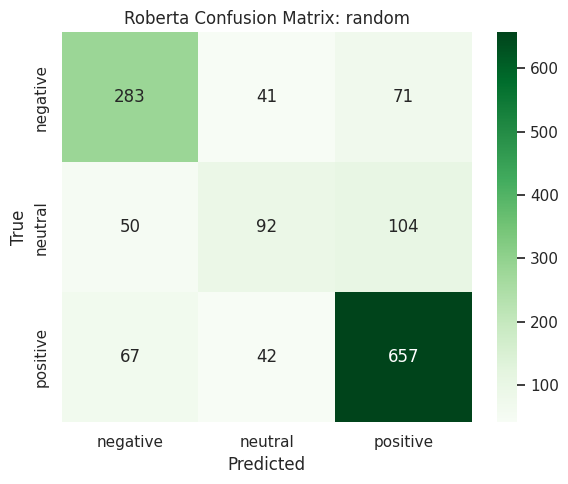

Running Roberta split: temporal


Map:   0%|          | 0/5624 [00:00<?, ? examples/s]

Map:   0%|          | 0/1407 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

    negative       0.68      0.75      0.71       368
     neutral       0.52      0.34      0.41       222
    positive       0.82      0.86      0.84       817

    accuracy                           0.75      1407
   macro avg       0.67      0.65      0.65      1407
weighted avg       0.74      0.75      0.74      1407



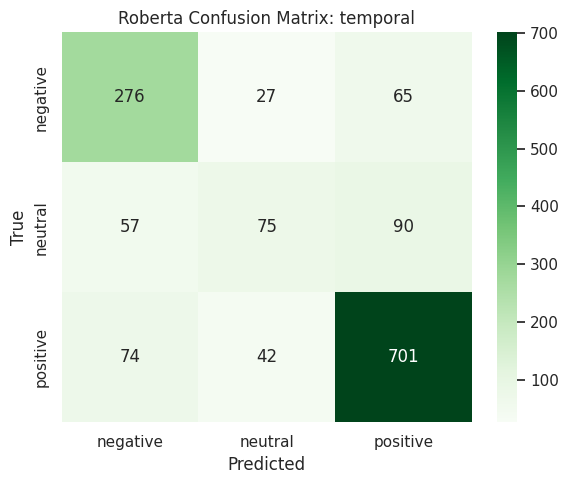

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
0,0.733475,0.674293,0.649381,0.657094,0.720448,0.733475,0.723952,0.856402,0.093313,roberta-base,Product-conditioned transformer,random
1,0.747690,0.672630,0.648618,0.653370,0.735067,0.747690,0.737565,0.870453,0.084472,roberta-base,Product-conditioned transformer,temporal


In [20]:
if RUN_BERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        TrainingArguments,
        Trainer,
    )

    def run_bert_for_split(train_df, test_df, split_name):
        train_bert = train_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()
        test_bert = test_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()

        train_ds = Dataset.from_pandas(train_bert)
        test_ds = Dataset.from_pandas(test_bert)

        tokenizer = AutoTokenizer.from_pretrained(Roberta_MODEL_NAME)

        def tokenize_batch(batch):
            return tokenizer(
                batch["model_input"],
                truncation=True,
                max_length=MAX_LENGTH,
            )

        train_ds = train_ds.map(tokenize_batch, batched=True)
        test_ds = test_ds.map(tokenize_batch, batched=True)

        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        id2label = {i: label for i, label in enumerate(class_names)}
        label2id = {label: i for i, label in enumerate(class_names)}

        model = AutoModelForSequenceClassification.from_pretrained(
            Roberta_MODEL_NAME,
            num_labels=n_classes,
            id2label=id2label,
            label2id=label2id,
        )

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            out = evaluate_model_outputs(labels, preds, None)
            return {
                "accuracy": out["Accuracy"],
                "macro_precision": out["Macro Precision"],
                "macro_recall": out["Macro Recall"],
                "macro_f1": out["Macro F1"],
                "weighted_f1": out["Weighted F1"],
            }

        args = TrainingArguments(
            output_dir=str(MODEL_DIR / f"roberta_{split_name}"),
            learning_rate=2e-5,
            per_device_train_batch_size=BERT_BATCH_SIZE,
            per_device_eval_batch_size=BERT_BATCH_SIZE,
            num_train_epochs=BERT_EPOCHS,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            logging_steps=50,
            report_to="none",
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        pred_output = trainer.predict(test_ds)

        logits = pred_output.predictions
        y_true = pred_output.label_ids
        y_pred = np.argmax(logits, axis=1)

        # Softmax probabilities.
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        y_prob = exp_logits / exp_logits.sum(axis=1, keepdims=True)

        metrics = evaluate_model_outputs(y_true, y_pred, y_prob)
        metrics.update({
            "Model": Roberta_MODEL_NAME,
            "Representation": "Product-conditioned transformer",
            "Split": split_name,
        })

        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
        plot_confusion_matrix(
            y_true,
            y_pred,
            title=f"Roberta Confusion Matrix: {split_name}",
            save_path=FIG_DIR / f"Roberta_confusion_{split_name}.png",
        )

        pred_df = test_df.copy()
        pred_df["predicted_sentiment"] = label_encoder.inverse_transform(y_pred)
        pred_df["true_sentiment"] = label_encoder.inverse_transform(y_true)
        pred_df["correct"] = pred_df["predicted_sentiment"] == pred_df["true_sentiment"]
        pred_df.to_csv(TABLE_DIR / f"roberta_predictions_{split_name}.csv", index=False)

        return pd.DataFrame([metrics]), pred_df

    rob_results = []
    rob_predictions = {}

    for split_name, (train_df, test_df) in splits.items():
        print("Running Roberta split:", split_name)
        res, pred_df = run_bert_for_split(train_df, test_df, split_name)
        rob_results.append(res)
        rob_predictions[split_name] = pred_df

    rob_results_df = pd.concat(rob_results, ignore_index=True)
    rob_results_df.to_csv(TABLE_DIR / "roberta_product_conditioned_results.csv", index=False)
    display(rob_results_df)
else:
    print("BERT is currently disabled. Set RUN_BERT = True to fine-tune Roberta.")

Running BERTweet split: random


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

    negative       0.65      0.66      0.65       395
     neutral       0.47      0.43      0.45       246
    positive       0.78      0.79      0.78       766

    accuracy                           0.69      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.69      0.69      0.69      1407



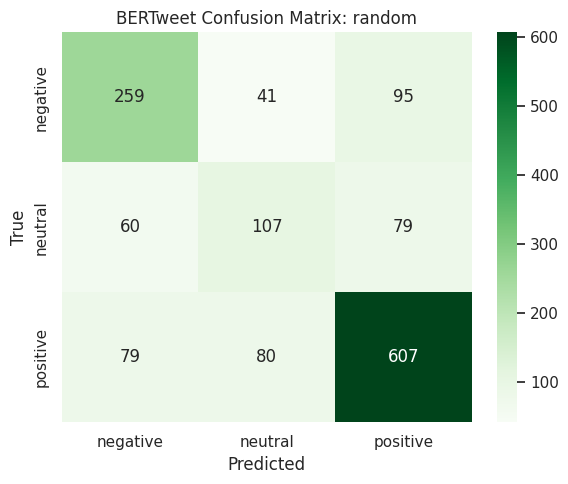

Running BERTweet split: temporal


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Map:   0%|          | 0/5624 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

              precision    recall  f1-score   support

    negative       0.66      0.67      0.67       368
     neutral       0.41      0.32      0.36       222
    positive       0.78      0.83      0.80       817

    accuracy                           0.71      1407
   macro avg       0.62      0.60      0.61      1407
weighted avg       0.69      0.71      0.70      1407



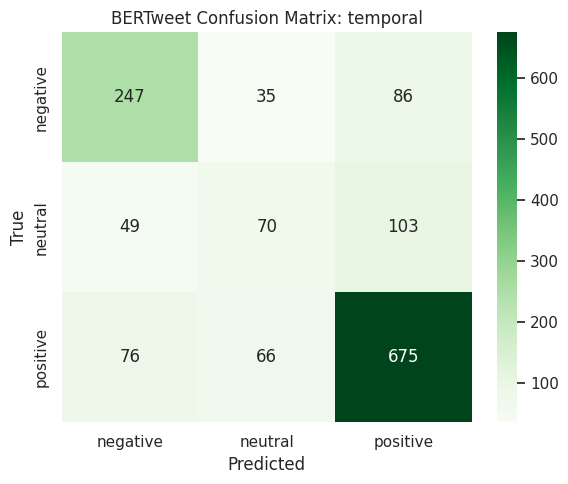

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
0,0.691542,0.632420,0.627695,0.629812,0.687873,0.691542,0.689551,0.820381,0.123676,vinai/bertweet-base,Product-conditioned transformer,random
1,0.705046,0.618195,0.604235,0.608965,0.691899,0.705046,0.697140,0.824661,0.169812,vinai/bertweet-base,Product-conditioned transformer,temporal


In [21]:
if RUN_BERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        TrainingArguments,
        Trainer,
    )

    def run_bert_for_split(train_df, test_df, split_name):
        train_bert = train_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()
        test_bert = test_df[["model_input", "label"]].rename(columns={"label": "labels"}).copy()

        train_bert["labels"] = train_bert["labels"].astype(int)
        test_bert["labels"] = test_bert["labels"].astype(int)

        assert train_bert["labels"].min() >= 0
        assert test_bert["labels"].min() >= 0
        assert train_bert["labels"].max() < n_classes
        assert test_bert["labels"].max() < n_classes

        train_ds = Dataset.from_pandas(train_bert)
        test_ds = Dataset.from_pandas(test_bert)

        tokenizer = AutoTokenizer.from_pretrained(
            Bertweet_MODEL_NAME,
            use_fast=False,
            normalization=True,
        )

        id2label = {i: label for i, label in enumerate(class_names)}
        label2id = {label: i for i, label in enumerate(class_names)}

        model = AutoModelForSequenceClassification.from_pretrained(
            Bertweet_MODEL_NAME,
            num_labels=n_classes,
            id2label=id2label,
            label2id=label2id,
        )

        model.resize_token_embeddings(len(tokenizer))

        bertweet_max_length = min(MAX_LENGTH, model.config.max_position_embeddings - 2)

        def tokenize_batch(batch):
            return tokenizer(
                batch["model_input"],
                truncation=True,
                max_length=bertweet_max_length,
            )

        train_ds = train_ds.map(tokenize_batch, batched=True)
        test_ds = test_ds.map(tokenize_batch, batched=True)

        if "token_type_ids" in train_ds.column_names:
            train_ds = train_ds.remove_columns(["token_type_ids"])

        if "token_type_ids" in test_ds.column_names:
            test_ds = test_ds.remove_columns(["token_type_ids"])

        train_ds = train_ds.remove_columns(
            [col for col in train_ds.column_names if col not in ["input_ids", "attention_mask", "labels"]]
        )

        test_ds = test_ds.remove_columns(
            [col for col in test_ds.column_names if col not in ["input_ids", "attention_mask", "labels"]]
        )

        data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

        print("Model name:", Bertweet_MODEL_NAME)
        print("Tokenizer length:", len(tokenizer))
        print("Model vocab size:", model.get_input_embeddings().weight.shape[0])
        print("Model max positions:", model.config.max_position_embeddings)
        print("Using max_length:", bertweet_max_length)

        sample = train_ds[0]
        print("Max token id sample:", max(sample["input_ids"]))
        print("Labels:", sorted(set(train_bert["labels"]).union(set(test_bert["labels"]))))
        print("n_classes:", n_classes)
        print("Dataset columns:", train_ds.column_names)

        max_train_token = max(max(x) for x in train_ds["input_ids"])
        max_test_token = max(max(x) for x in test_ds["input_ids"])
        embedding_size = model.get_input_embeddings().weight.shape[0]

        print("Max train token:", max_train_token)
        print("Max test token:", max_test_token)
        print("Embedding size:", embedding_size)

        assert max_train_token < embedding_size
        assert max_test_token < embedding_size

        test_batch = data_collator([train_ds[i] for i in range(min(2, len(train_ds)))])
        model.eval()

        with torch.no_grad():
            test_out = model(**test_batch)

        print("Pre-Trainer forward pass logits shape:", test_out.logits.shape)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            out = evaluate_model_outputs(labels, preds, None)
            return {
                "accuracy": out["Accuracy"],
                "macro_precision": out["Macro Precision"],
                "macro_recall": out["Macro Recall"],
                "macro_f1": out["Macro F1"],
                "weighted_f1": out["Weighted F1"],
            }

        args = TrainingArguments(
            output_dir=str(MODEL_DIR / f"bertweet_{split_name}"),
            learning_rate=2e-5,
            per_device_train_batch_size=4,
            per_device_eval_batch_size=4,
            num_train_epochs=BERT_EPOCHS,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            logging_steps=50,
            report_to="none",
            fp16=False,
            bf16=False,
            use_cpu=True,
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=test_ds,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        trainer.train()
        pred_output = trainer.predict(test_ds)

        logits = pred_output.predictions
        y_true = pred_output.label_ids
        y_pred = np.argmax(logits, axis=1)

        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        y_prob = exp_logits / exp_logits.sum(axis=1, keepdims=True)

        metrics = evaluate_model_outputs(y_true, y_pred, y_prob)
        metrics.update({
            "Model": Bertweet_MODEL_NAME,
            "Representation": "Product-conditioned transformer",
            "Split": split_name,
        })

        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
        plot_confusion_matrix(
            y_true,
            y_pred,
            title=f"BERTweet Confusion Matrix: {split_name}",
            save_path=FIG_DIR / f"bertweet_confusion_{split_name}.png",
        )

        pred_df = test_df.copy()
        pred_df["predicted_sentiment"] = label_encoder.inverse_transform(y_pred)
        pred_df["true_sentiment"] = label_encoder.inverse_transform(y_true)
        pred_df["correct"] = pred_df["predicted_sentiment"] == pred_df["true_sentiment"]
        pred_df.to_csv(TABLE_DIR / f"bertweet_predictions_{split_name}.csv", index=False)

        return pd.DataFrame([metrics]), pred_df

    bertweet_results = []
    bertweet_predictions = {}

    for split_name, (train_df, test_df) in splits.items():
        print("Running BERTweet split:", split_name)
        res, pred_df = run_bert_for_split(train_df, test_df, split_name)
        bertweet_results.append(res)
        bertweet_predictions[split_name] = pred_df

    bertweet_results_df = pd.concat(bertweet_results, ignore_index=True)
    bertweet_results_df.to_csv(TABLE_DIR / "bertweet_product_conditioned_results.csv", index=False)
    display(bertweet_results_df)

else:
    print("BERT is currently disabled. Set RUN_BERT = True to fine-tune BERTweet.")

## Error analysis

In [22]:
SPLIT_FOR_ERROR_ANALYSIS = "temporal" if "temporal" in splits else "random"

candidate_rows = classical_results_df[
    (classical_results_df["Split"] == SPLIT_FOR_ERROR_ANALYSIS) &
    (classical_results_df["Representation"] == "Product-conditioned TF-IDF")
].sort_values("Macro F1", ascending=False)

MODEL_FOR_ERROR_ANALYSIS = candidate_rows.iloc[0]["Model"]
print("Using split:", SPLIT_FOR_ERROR_ANALYSIS)
print("Using model:", MODEL_FOR_ERROR_ANALYSIS)

out = all_classical_outputs[SPLIT_FOR_ERROR_ANALYSIS][("Product-conditioned TF-IDF", MODEL_FOR_ERROR_ANALYSIS)]
error_df = out["test_df"].copy()
error_df["true_sentiment"] = label_encoder.inverse_transform(out["y_true"])
error_df["predicted_sentiment"] = label_encoder.inverse_transform(out["y_pred"])
error_df["correct"] = error_df["true_sentiment"] == error_df["predicted_sentiment"]

misclassified = error_df[~error_df["correct"]].copy()
misclassified.to_csv(TABLE_DIR / "misclassified_examples_product_conditioned.csv", index=False)

print("Total test examples:", len(error_df))
print("Misclassified examples:", len(misclassified))
display(misclassified[["text_id", "product", "true_sentiment", "predicted_sentiment", "text"]].head(25))

Using split: temporal
Using model: LinearSVC
Total test examples: 1407
Misclassified examples: 597


,text_id,product,true_sentiment,predicted_sentiment,text
0,l6l4uwk,vape,positive,negative,carts sure. Vaping dry flower would make no se...
3,l6m2j3d,oil,neutral,positive,Aside from chlorophyll giving it a pretty nast...
6,l6mbqg5,flower,positive,negative,Damn why are people vaping carts for their fir...
11,l6mpyxb,flower,neutral,negative,The third time I ever had edibles was about 6 ...
14,l6nklvu,oil,neutral,positive,If I ever had an issue like this I hit it with...
18,l6odxhx,flower,negative,positive,"A water pipe, still used for smoking, isn’t go..."
20,l6onnm8,gummies,positive,negative,"It’s all in your head, now that it’s happened ..."
21,l6onnm8,vape,positive,negative,"It’s all in your head, now that it’s happened ..."
24,l6py561,oil,positive,negative,to avoid bad dreams during t breaks or off day...
28,l6qb3bz,oil,positive,neutral,I got a chance to try some of Alliant’s cherry...


In [23]:
error_breakdown = (
    misclassified.groupby(["product", "true_sentiment", "predicted_sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_breakdown.to_csv(TABLE_DIR / "error_breakdown_by_product_sentiment.csv", index=False)
display(error_breakdown.head(30))

,product,true_sentiment,predicted_sentiment,count
27,vape,positive,negative,48
24,vape,negative,positive,41
15,oil,neutral,positive,40
7,gummies,negative,positive,40
4,flower,positive,negative,40
10,gummies,positive,negative,36
1,flower,negative,positive,36
3,flower,neutral,positive,34
13,oil,negative,positive,33
26,vape,neutral,positive,32


Split,Representation,random,temporal,Temporal F1 drop
0,Product-conditioned TF-IDF,0.494663,0.450642,0.044021
1,Product-only TF-IDF,0.330410,0.343410,-0.013000


,product,n_examples,error_rate
4,vape,351,0.484330
0,flower,314,0.458599
1,gummies,351,0.418803
2,oil,352,0.349432
3,topical,39,0.333333


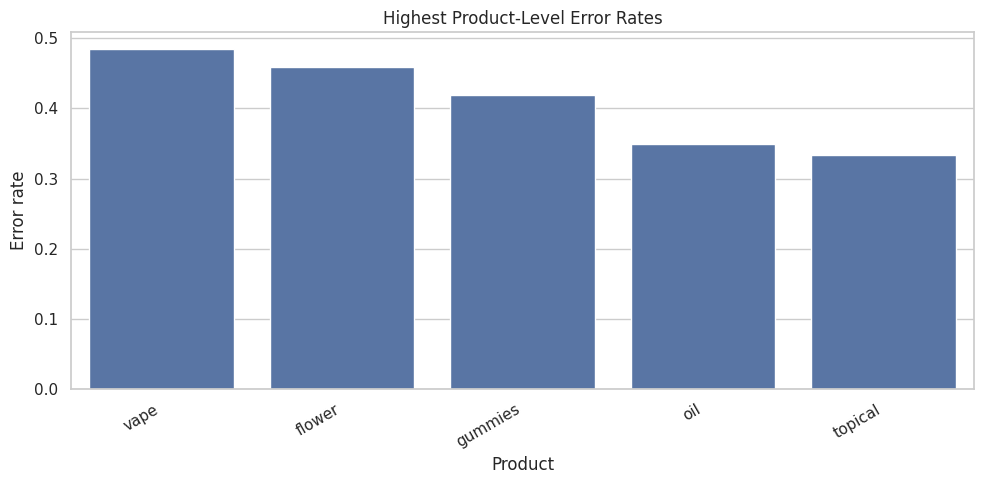

In [24]:
# Compare random vs temporal performance for the best model in each representation.
if "temporal" in classical_results_df["Split"].unique():
    robustness_df = ablation_summary_df.pivot_table(
        index="Representation",
        columns="Split",
        values="Macro F1",
        aggfunc="max"
    ).reset_index()
    if {"random", "temporal"}.issubset(robustness_df.columns):
        robustness_df["Temporal F1 drop"] = robustness_df["random"] - robustness_df["temporal"]
    robustness_df.to_csv(TABLE_DIR / "temporal_robustness_summary.csv", index=False)
    display(robustness_df)
else:
    print("Temporal split was not available, so temporal robustness analysis was skipped.")

# Product-level error rates for the selected product-conditioned model.
product_error_rates = (
    error_df.groupby("product")
    .agg(
        n_examples=("correct", "size"),
        error_rate=("correct", lambda s: 1 - s.mean())
    )
    .reset_index()
    .sort_values(["error_rate", "n_examples"], ascending=[False, False])
)
product_error_rates.to_csv(TABLE_DIR / "product_level_error_rates.csv", index=False)
display(product_error_rates.head(20))

plt.figure(figsize=(10, 5))
sns.barplot(data=product_error_rates.head(15), x="product", y="error_rate")
plt.title("Highest Product-Level Error Rates")
plt.xlabel("Product")
plt.ylabel("Error rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "product_level_error_rates.png", dpi=300)
plt.show()

## 12. Final comparison table

In [25]:
tables = [classical_results_df, cv_results_df]

if "bert_results_df" in globals():
    tables.append(bert_results_df)

if "rob_results_df" in globals():
    tables.append(rob_results_df)
if "bertweet_results_df" in globals():
    tables.append(bertweet_results_df)

final_results_df = pd.concat(tables, ignore_index=True, sort=False)
final_results_df = final_results_df.sort_values(["Split", "Macro F1"], ascending=[True, False])
final_results_df.to_csv(TABLE_DIR / "final_model_comparison.csv", index=False)

display(final_results_df)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUROC,ECE,Model,Representation,Split
20,0.575452,0.517956,0.504221,0.509610,0.565819,0.575452,0.569457,NaN,NaN,Logistic Regression,Product-conditioned TF-IDF,10-fold CV
23,0.733475,0.674293,0.649381,0.657094,0.720448,0.733475,0.723952,0.856402,0.093313,roberta-base,Product-conditioned transformer,random
25,0.691542,0.632420,0.627695,0.629812,0.687873,0.691542,0.689551,0.820381,0.123676,vinai/bertweet-base,Product-conditioned transformer,random
21,0.621891,0.570369,0.517802,0.522774,0.606962,0.621891,0.601786,0.744456,0.110992,distilbert-base-uncased,Product-conditioned transformer,random
0,0.573561,0.520513,0.484742,0.494663,0.557856,0.573561,0.559991,0.695315,0.077131,Logistic Regression,Product-conditioned TF-IDF,random
1,0.535181,0.484817,0.485262,0.485036,0.535161,0.535181,0.535169,NaN,NaN,LinearSVC,Product-conditioned TF-IDF,random
2,0.552239,0.505469,0.431117,0.438041,0.527145,0.552239,0.516929,0.647268,0.079458,Random Forest,Product-conditioned TF-IDF,random
3,0.501777,0.415124,0.387446,0.387370,0.464427,0.501777,0.471114,0.579686,0.320330,Decision Tree,Product-conditioned TF-IDF,random
4,0.560768,0.564037,0.379723,0.344256,0.549808,0.560768,0.462175,0.666494,0.052338,Naive Bayes,Product-conditioned TF-IDF,random
5,0.442075,0.341346,0.365188,0.330410,0.428824,0.442075,0.419388,0.528784,0.083235,Random Forest,Product-only TF-IDF,random


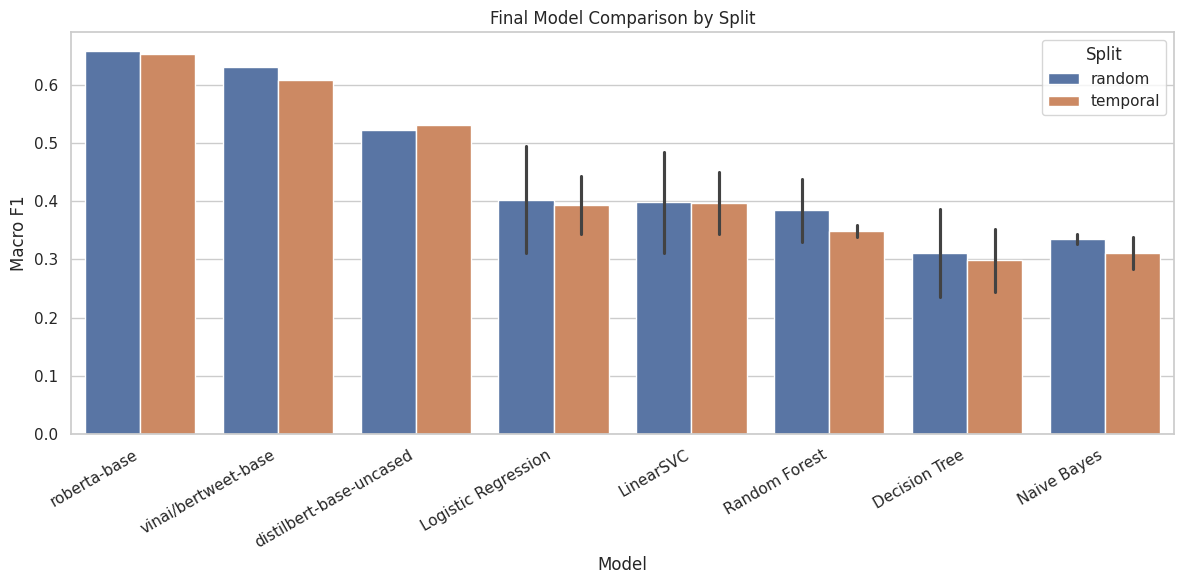

In [26]:
plt.figure(figsize=(12, 6))
plot_final = final_results_df[final_results_df["Split"].isin(["random", "temporal"])].copy()

sns.barplot(data=plot_final, x="Model", y="Macro F1", hue="Split")
plt.title("Final Model Comparison by Split")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "final_model_comparison_macro_f1.png", dpi=300)
plt.show()

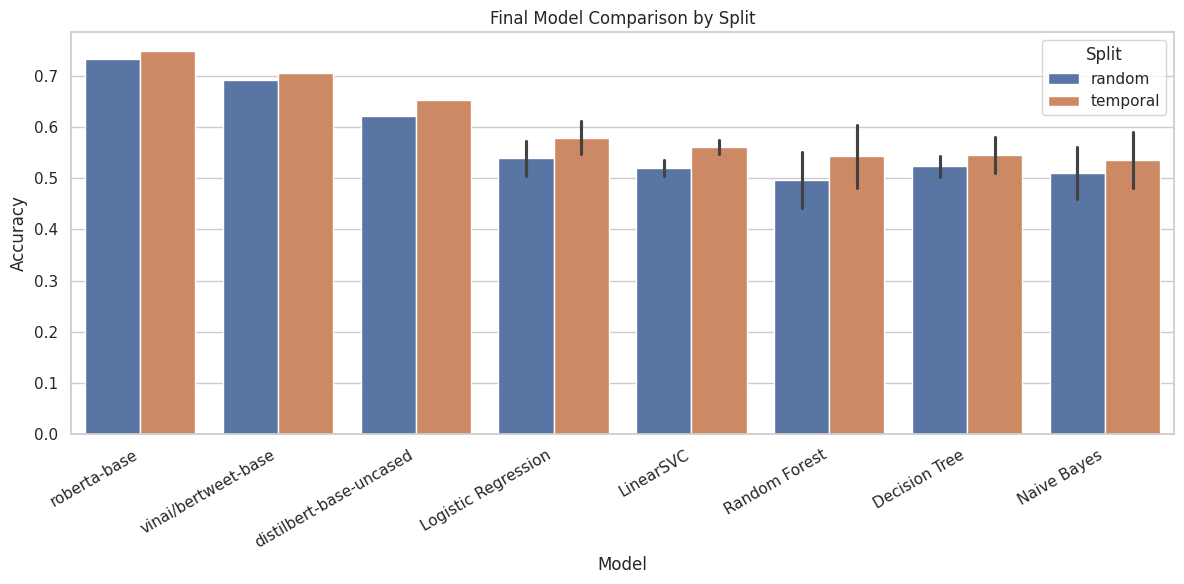

In [27]:
plt.figure(figsize=(12, 6))
plot_final = final_results_df[final_results_df["Split"].isin(["random", "temporal"])].copy()

sns.barplot(data=plot_final, x="Model", y="Accuracy", hue="Split")
plt.title("Final Model Comparison by Split")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "final_model_comparison_Accuracy.png", dpi=300)
plt.show()

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

text_col = "text"
label_col = "sentiment"

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000
)

X = vectorizer.fit_transform(df[text_col].astype(str))
terms = np.array(vectorizer.get_feature_names_out())

labels = sorted(df[label_col].unique())
top_words = {}

for label in labels:
    in_class = df[label_col] == label

    class_counts = np.asarray(X[in_class.values].sum(axis=0)).ravel() + 1
    other_counts = np.asarray(X[~in_class.values].sum(axis=0)).ravel() + 1

    class_total = class_counts.sum()
    other_total = other_counts.sum()

    log_odds = np.log(class_counts / class_total) - np.log(other_counts / other_total)

    top_idx = log_odds.argsort()[::-1][:20]
    top_words[label] = terms[top_idx]

top_words_df = pd.DataFrame(dict([
    (label, pd.Series(words))
    for label, words in top_words.items()
]))

display(top_words_df)
top_words_df.to_csv(TABLE_DIR / "top_sentiment_words_log_odds.csv", index=False)

,negative,neutral,positive
0,homies,assumption,combat anxiety
1,pharmacy,let say,personally like
2,laying,intensities,ashwagandha
3,boof,thc assumption,does cbd
4,dead,different results,optimal dose
5,keif,edible tolerance,ultimate cbd
6,god knows,smellproof,cruise
7,male,pax2,albuterol
8,eat edibles,produce different,dosage guide
9,media,exacerbating,seroquel


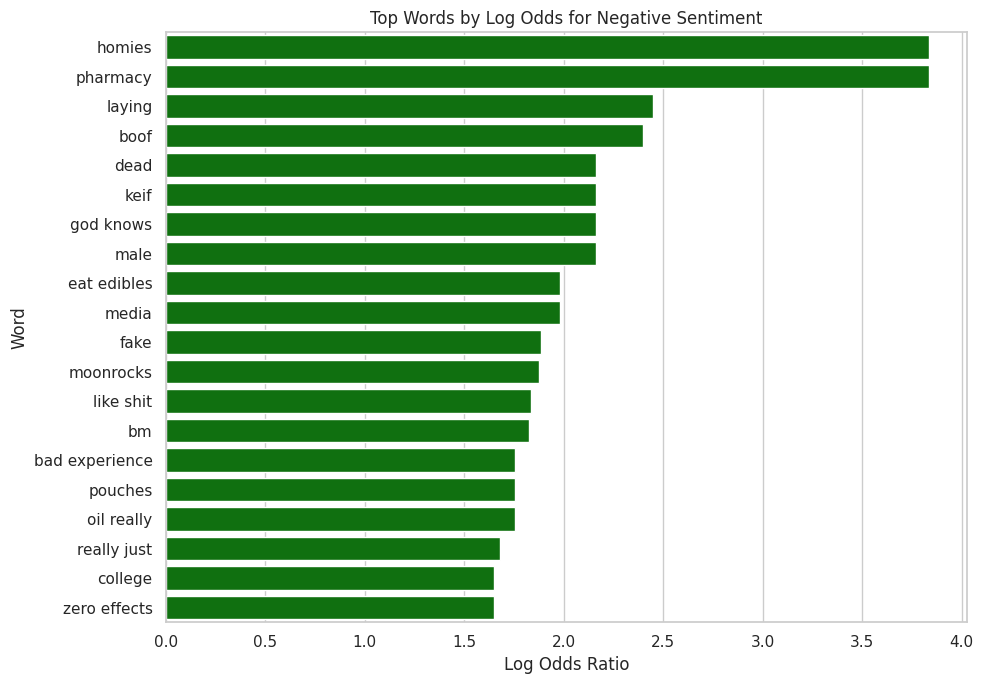

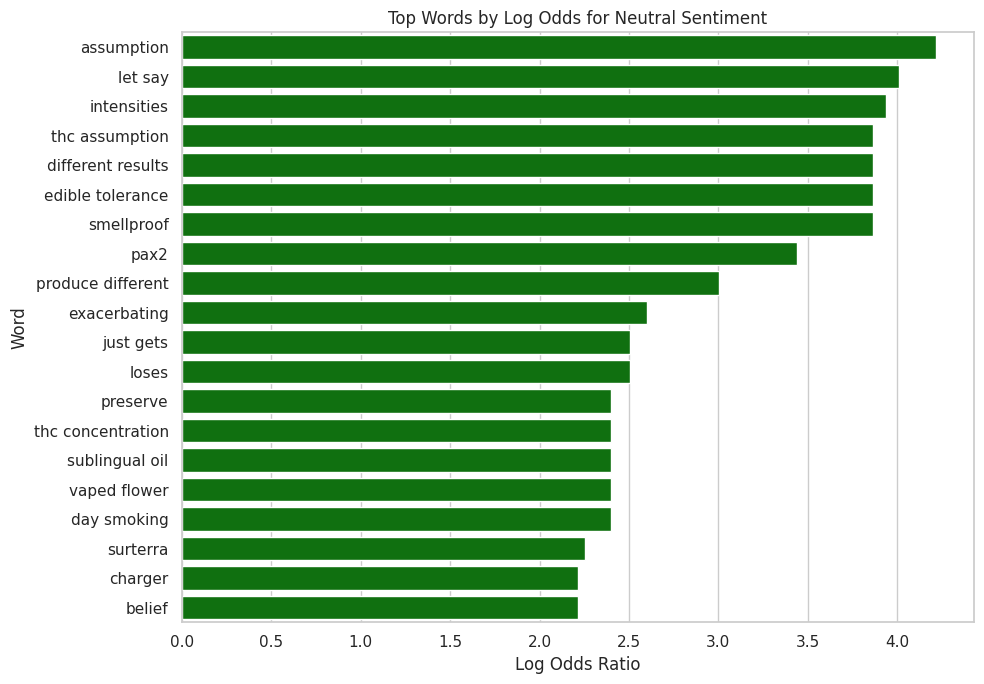

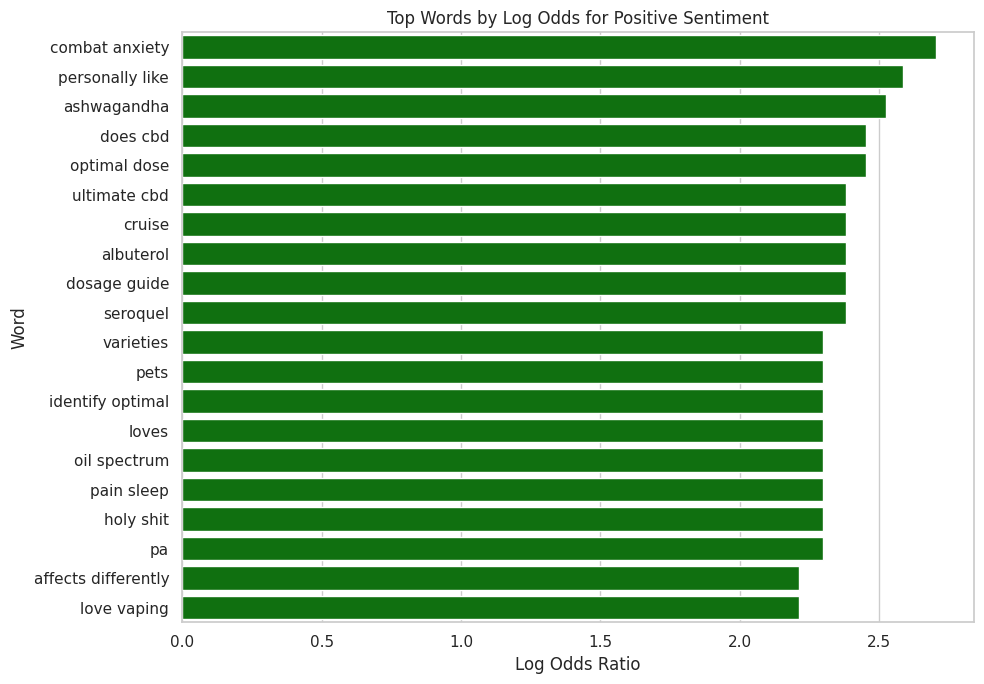

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-calculate log odds and prepare data for plotting
plot_data = []

for label in labels:
    in_class = df[label_col] == label

    class_counts = np.asarray(X[in_class.values].sum(axis=0)).ravel() + 1
    other_counts = np.asarray(X[~in_class.values].sum(axis=0)).ravel() + 1

    class_total = class_counts.sum()
    other_total = other_counts.sum()

    log_odds = np.log(class_counts / class_total) - np.log(other_counts / other_total)

    top_idx = log_odds.argsort()[::-1][:20] # Get top 20 words by log odds

    for i in top_idx:
        plot_data.append({
            "Sentiment": label,
            "Word": terms[i],
            "Log Odds": log_odds[i]
        })

plot_df = pd.DataFrame(plot_data)

for sentiment_label in labels:
    subset = plot_df[plot_df["Sentiment"] == sentiment_label].sort_values("Log Odds", ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        x="Log Odds",
        y="Word",
        data=subset,
        order=subset["Word"],
        color="Green"
    )
    plt.title(f"Top Words by Log Odds for {sentiment_label.capitalize()} Sentiment")
    plt.xlabel("Log Odds Ratio")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"top_words_log_odds_{sentiment_label}.png", dpi=300)
    plt.show()

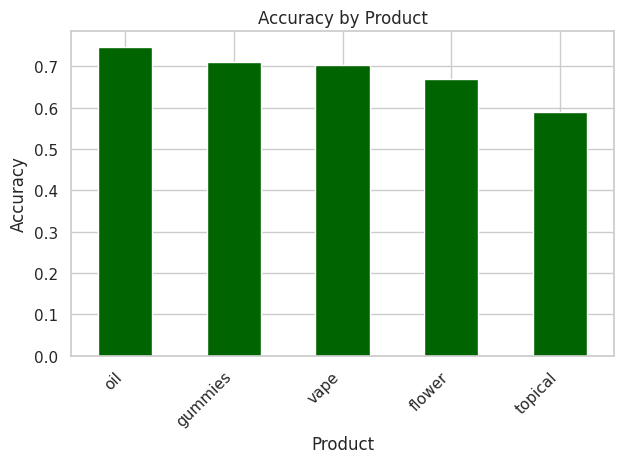

In [30]:
product_perf = pred_df.groupby("product").apply(
    lambda x: accuracy_score(x["true_sentiment"], x["predicted_sentiment"])
)

product_perf = product_perf.sort_values(ascending=False)

product_perf.plot(kind="bar", color="DarkGreen")  # light green
plt.title("Accuracy by Product")
plt.ylabel("Accuracy")
plt.xlabel("Product")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Setup ROC

In [31]:
sklearn.metrics import roc_curve, auc, roc_auc_score

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

BASE_DIR  = Path.cwd()
DATA_PATH = BASE_DIR / "pair_level_gpt41mini_clean_with_text.csv"
MODEL_DIR = BASE_DIR / "models_pair_level"
OUT_FIG   = BASE_DIR / "figures_pair_level"
OUT_TBL   = BASE_DIR / "tables_pair_level"
OUT_FIG.mkdir(exist_ok=True, parents=True)
OUT_TBL.mkdir(exist_ok=True, parents=True)

assert DATA_PATH.exists(), f"Missing {DATA_PATH}"
print("Data:", DATA_PATH)
print("Model dir:", MODEL_DIR, "| exists:", MODEL_DIR.exists())

torch: 2.10.0+cu128 | cuda: True
Data: /content/pair_level_gpt41mini_clean_with_text.csv
Model dir: /content/models_pair_level | exists: True


load data

In [32]:
df = pd.read_csv(DATA_PATH)
df["text"] = df["text"].astype(str).fillna("")
df["product"] = df["product"].astype(str).fillna("Unknown")
df["sentiment"] = df["sentiment"].astype(str).str.strip()
df["date_utc"] = pd.to_datetime(df["date_utc"], errors="coerce", utc=True)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])
class_names = list(label_encoder.classes_)
n_classes = len(class_names)

df["model_input"] = (
    "Product: " + df["product"].astype(str)
    + ". Text: " + df["text"].astype(str)
)
print("Class mapping:", dict(zip(class_names, range(n_classes))))
print("Rows:", len(df))

def make_random_split(df, test_size=0.20):
    tr, te = train_test_split(
        df, test_size=test_size, random_state=RANDOM_STATE, stratify=df["label"]
    )
    return tr.reset_index(drop=True), te.reset_index(drop=True)

def make_temporal_split(df, train_frac=0.80):
    dated = df.dropna(subset=["date_utc"]).sort_values("date_utc").reset_index(drop=True)
    cut = int(len(dated) * train_frac)
    return dated.iloc[:cut].copy().reset_index(drop=True), dated.iloc[cut:].copy().reset_index(drop=True)

splits = {"random": make_random_split(df), "temporal": make_temporal_split(df)}
for name, (tr, te) in splits.items():
    print(f"{name}: train={len(tr)}, test={len(te)}")

Class mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Rows: 7031
random: train=5624, test=1407
temporal: train=5624, test=1407


Helper

In [33]:
def macro_auc_ovr(y_true_bin, y_prob):
    return roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")

def macro_curve(y_true_bin, y_prob):
    """Interpolated macro-average ROC -> (fpr_grid, mean_tpr, macro_auc)."""
    fprs, tprs = [], []
    for i in range(n_classes):
        f, t, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        fprs.append(f); tprs.append(t)
    grid = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(grid)
    for f, t in zip(fprs, tprs):
        mean_tpr += np.interp(grid, f, t)
    mean_tpr /= n_classes
    return grid, mean_tpr, macro_auc_ovr(y_true_bin, y_prob)

def plot_per_class(y_true_bin, y_prob, title, out_path):
    plt.figure(figsize=(6.5, 5.5))
    m_auc = macro_auc_ovr(y_true_bin, y_prob)
    for i, c in enumerate(class_names):
        f, t, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        plt.plot(f, t, label=f"{c}  AUC={auc(f, t):.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
    plt.title(f"{title}\nmacro AUC = {m_auc:.3f}")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.legend(loc="lower right", fontsize=9); plt.tight_layout()
    plt.savefig(out_path, dpi=200); plt.show()

def resolve_checkpoint(p: Path):
    if not p.exists():
        return None
    if (p / "config.json").exists():
        return p
    cands = sorted(p.glob("checkpoint-*"))
    return cands[-1] if cands else None

@torch.no_grad()
def predict_proba_transformer(ckpt: Path, texts, batch_size=16, max_length=256, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(str(ckpt))
    mdl = AutoModelForSequenceClassification.from_pretrained(str(ckpt)).to(device).eval()
    chunks = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i : i + batch_size])
        enc = tok(batch, padding=True, truncation=True,
                  max_length=max_length, return_tensors="pt").to(device)
        chunks.append(mdl(**enc).logits.cpu().numpy())
    logits = np.concatenate(chunks, axis=0)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

Lopreg

In [34]:
from sklearn.multiclass import OneVsRestClassifier

def make_tfidf_logreg():
    # Newer sklearn refuses implicit OvR with liblinear, so wrap explicitly.
    # Same one-vs-rest semantics as the paper's training run.
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, stop_words="english", ngram_range=(1, 3),
            min_df=2, max_df=0.95, max_features=50000, sublinear_tf=True,
        )),
        ("clf", OneVsRestClassifier(LogisticRegression(
            max_iter=3000, class_weight="balanced", solver="liblinear",
        ))),
    ])

logreg_probs = {}
for split_name, (train_df, test_df) in splits.items():
    pipe = make_tfidf_logreg()
    pipe.fit(train_df["model_input"].values, train_df["label"].values)
    y_prob = pipe.predict_proba(test_df["model_input"].values)
    logreg_probs[split_name] = (test_df["label"].values, y_prob)
    yb = label_binarize(test_df["label"].values, classes=np.arange(n_classes))
    print(f"LogReg {split_name}: macro AUC = {macro_auc_ovr(yb, y_prob):.3f}")

LogReg random: macro AUC = 0.695
LogReg temporal: macro AUC = 0.673


transfermor interence

In [35]:
TRANSFORMERS = [("DistilBERT", "distilbert"), ("RoBERTa", "roberta")]
transformer_probs = {}  # (key, split) -> (y_true, y_prob)

for split_name, (_, test_df) in splits.items():
    for display_name, key in TRANSFORMERS:
        ckpt_root = MODEL_DIR / f"{key}_{split_name}"
        ckpt = resolve_checkpoint(ckpt_root)
        if ckpt is None:
            print(f"!! checkpoint missing: {ckpt_root} -- SKIPPING {display_name}/{split_name}")
            continue
        print(f"[{split_name}] {display_name}: loading {ckpt}")
        y_prob = predict_proba_transformer(ckpt, test_df["model_input"].tolist())
        transformer_probs[(key, split_name)] = (test_df["label"].values, y_prob)
        yb = label_binarize(test_df["label"].values, classes=np.arange(n_classes))
        print(f"    macro AUC = {macro_auc_ovr(yb, y_prob):.3f}")

[random] DistilBERT: loading /content/models_pair_level/distilbert_random/checkpoint-704


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

    macro AUC = 0.747
[random] RoBERTa: loading /content/models_pair_level/roberta_random/checkpoint-704


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

    macro AUC = 0.850
[temporal] DistilBERT: loading /content/models_pair_level/distilbert_temporal/checkpoint-704


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

    macro AUC = 0.754
[temporal] RoBERTa: loading /content/models_pair_level/roberta_temporal/checkpoint-704


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

    macro AUC = 0.861


pre class roc

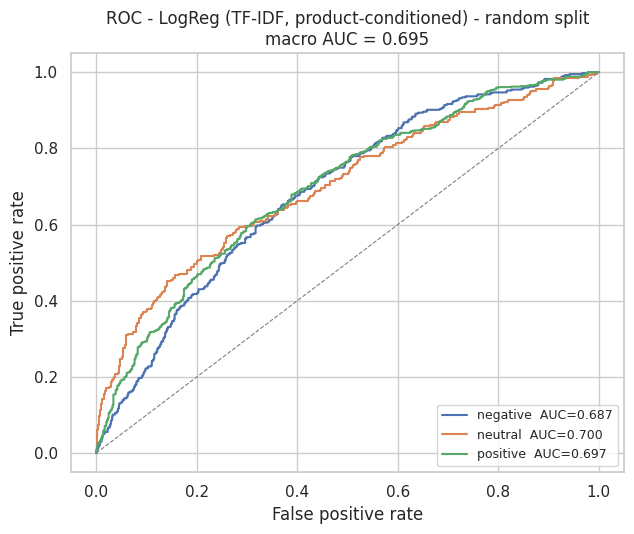

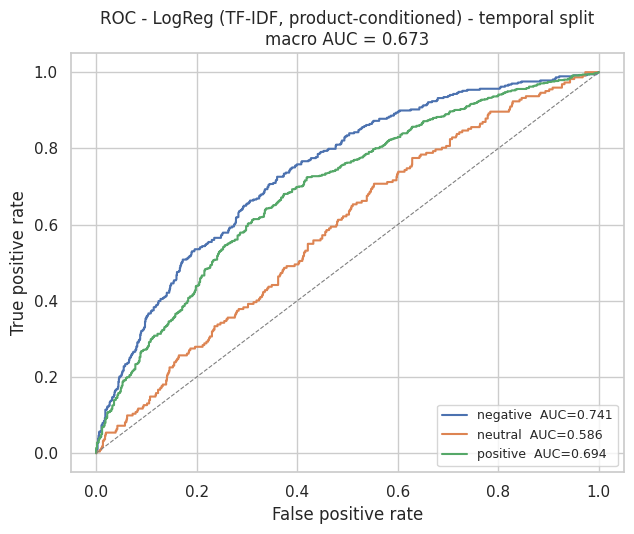

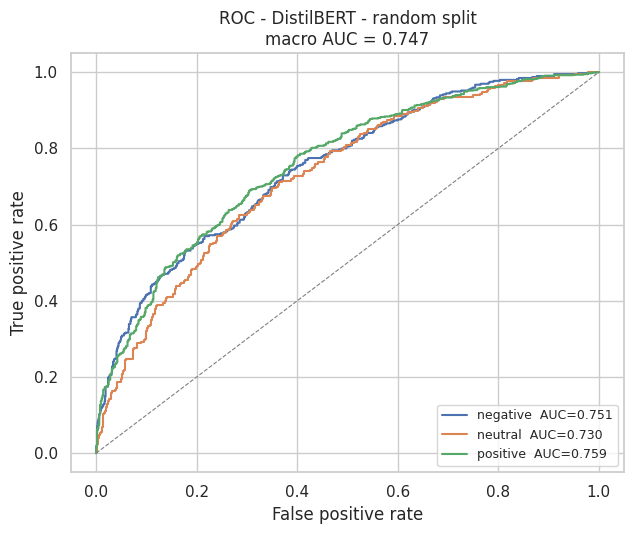

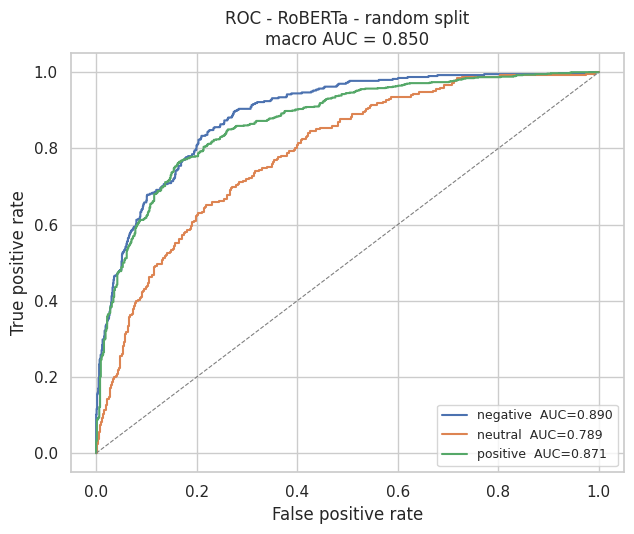

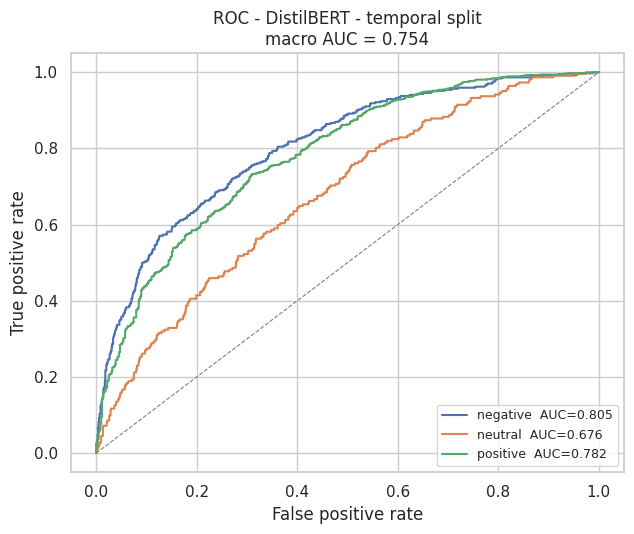

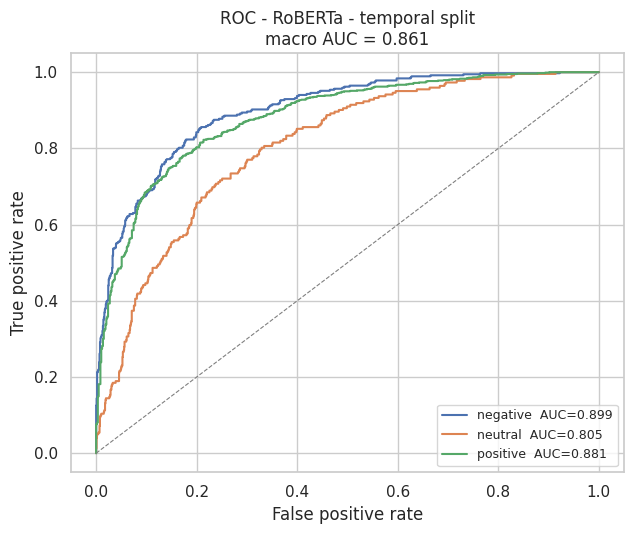

In [42]:
# LogReg per-class
for split_name, (y_true, y_prob) in logreg_probs.items():
    yb = label_binarize(y_true, classes=np.arange(n_classes))
    plot_per_class(
        yb, y_prob,
        title=f"ROC - LogReg (TF-IDF, product-conditioned) - {split_name} split",
        out_path=OUT_FIG / f"roc_logistic_regression_{split_name}.png",
    )

# Transformers per-class
for (key, split_name), (y_true, y_prob) in transformer_probs.items():
    yb = label_binarize(y_true, classes=np.arange(n_classes))
    display_name = {k: n for n, k in TRANSFORMERS}[key]
    plot_per_class(
        yb, y_prob,
        title=f"ROC - {display_name} - {split_name} split",
        out_path=OUT_FIG / f"roc_{key}_{split_name}.png",
    )

final roc

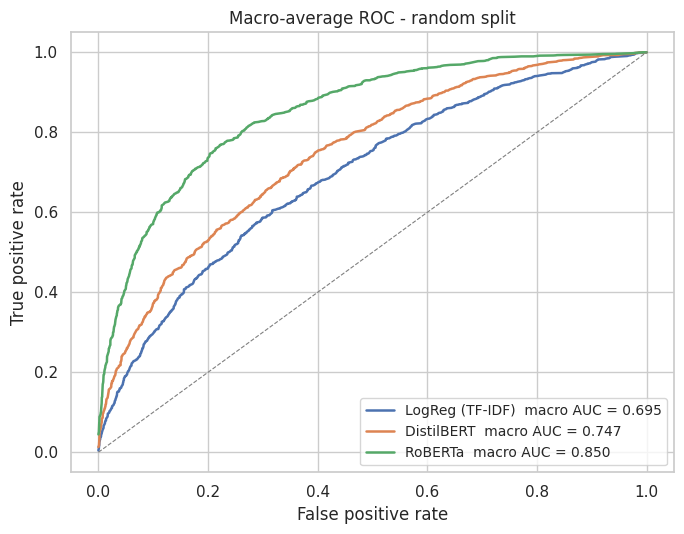

wrote /content/figures_pair_level/final_roc_overlay_random.png


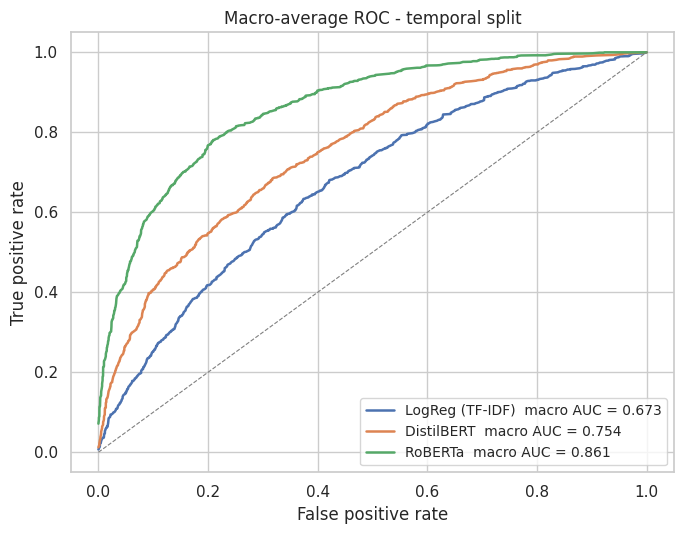

wrote /content/figures_pair_level/final_roc_overlay_temporal.png


In [43]:
def plot_overlay(split_name):
    curves = []
    # LogReg
    y_true_lr, y_prob_lr = logreg_probs[split_name]
    yb_lr = label_binarize(y_true_lr, classes=np.arange(n_classes))
    curves.append(("LogReg (TF-IDF)", *macro_curve(yb_lr, y_prob_lr)))
    # Transformers
    for display_name, key in TRANSFORMERS:
        item = transformer_probs.get((key, split_name))
        if item is None:
            continue
        y_true, y_prob = item
        yb = label_binarize(y_true, classes=np.arange(n_classes))
        curves.append((display_name, *macro_curve(yb, y_prob)))

    plt.figure(figsize=(7, 5.5))
    for label, f, t, a in curves:
        plt.plot(f, t, label=f"{label}  macro AUC = {a:.3f}", linewidth=1.8)
    plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
    plt.title(f"Macro-average ROC - {split_name} split")
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.legend(loc="lower right", fontsize=10); plt.tight_layout()
    out = OUT_FIG / f"final_roc_overlay_{split_name}.png"
    plt.savefig(out, dpi=200); plt.show()
    print("wrote", out)
    return curves

_ = plot_overlay("random")
_ = plot_overlay("temporal")

auc sum

In [45]:
rows = []
for split_name, (y_true, y_prob) in logreg_probs.items():
    yb = label_binarize(y_true, classes=np.arange(n_classes))
    row = {"Model": "LogReg (TF-IDF)", "Split": split_name,
           "Macro AUC": macro_auc_ovr(yb, y_prob)}
    for i, c in enumerate(class_names):
        f, t, _ = roc_curve(yb[:, i], y_prob[:, i])
        row[f"AUC ({c})"] = auc(f, t)
    rows.append(row)

for (key, split_name), (y_true, y_prob) in transformer_probs.items():
    display_name = {k: n for n, k in TRANSFORMERS}[key]
    yb = label_binarize(y_true, classes=np.arange(n_classes))
    row = {"Model": display_name, "Split": split_name,
           "Macro AUC": macro_auc_ovr(yb, y_prob)}
    for i, c in enumerate(class_names):
        f, t, _ = roc_curve(yb[:, i], y_prob[:, i])
        row[f"AUC ({c})"] = auc(f, t)
    rows.append(row)

auc_df = pd.DataFrame(rows).sort_values(["Split", "Macro AUC"], ascending=[True, False])
out = OUT_TBL / "auc_summary.csv"
auc_df.to_csv(out, index=False)
print("Wrote", out)
auc_df

Wrote /content/tables_pair_level/auc_summary.csv


,Model,Split,Macro AUC,AUC (negative),AUC (neutral),AUC (positive)
3,RoBERTa,random,0.850142,0.890359,0.789465,0.870602
2,DistilBERT,random,0.746573,0.750929,0.730160,0.758629
0,LogReg (TF-IDF),random,0.694713,0.687461,0.700062,0.696616
5,RoBERTa,temporal,0.861358,0.898702,0.804609,0.880763
4,DistilBERT,temporal,0.754288,0.804723,0.676316,0.781825
1,LogReg (TF-IDF),temporal,0.673340,0.740764,0.585614,0.693644


Table 3 Data

In [52]:

# ---- ECE (matches the helper from your original notebook) -----------------
def multiclass_ece(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    conf = y_prob.max(axis=1); pred = y_prob.argmax(axis=1)
    acc = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for i in range(n_bins):
        m = (conf > edges[i]) & (conf <= edges[i + 1])
        if m.any():
            ece += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return ece

def metrics_row(y_true, y_pred, y_prob):
    _, _, mac_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    _, _, w_f1, _   = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    out = {
        "Accuracy":   accuracy_score(y_true, y_pred),
        "Macro-F1":   mac_f1,
        "Weighted-F1": w_f1,
    }
    if y_prob is not None:
        yb = label_binarize(y_true, classes=np.arange(n_classes))
        out["Macro-AUROC"] = roc_auc_score(yb, y_prob, average="macro", multi_class="ovr")
        out["ECE"]         = multiclass_ece(y_true, y_prob)
    return out

# ---- helpers to compute extra rows the ROC notebook didn't already have ----
def tfidf():
    return TfidfVectorizer(
        lowercase=True, stop_words="english", ngram_range=(1, 3),
        min_df=2, max_df=0.95, max_features=50000, sublinear_tf=True,
    )

def fit_eval(clf, train_df, test_df, input_col):
    pipe = Pipeline([("tfidf", tfidf()), ("clf", clf)])
    pipe.fit(train_df[input_col].values, train_df["label"].values)
    yt = test_df["label"].values
    yp = pipe.predict(test_df[input_col].values)
    pr = pipe.predict_proba(test_df[input_col].values) if hasattr(pipe, "predict_proba") else None
    return yt, yp, pr

# Row 1: Random Forest, Product-only TF-IDF, random
# Remove redundant creation of df["input_product_only"] as splits are already generated
# df["input_product_only"] = "Product: " + df["product"].astype(str)

tr_r, te_r = splits["random"]
# Ensure 'input_product_only' is present in tr_r and te_r
tr_r["input_product_only"] = "Product: " + tr_r["product"].astype(str)
te_r["input_product_only"] = "Product: " + te_r["product"].astype(str)

yt, yp, pr = fit_eval(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                           class_weight="balanced_subsample", n_jobs=-1),
    tr_r, te_r, "input_product_only")
rows = [{"Model": "Random Forest",
         "Representation / split": "Product-only TF-IDF, random",
         **metrics_row(yt, yp, pr)}]

# Row 2: Logistic Regression, Product-conditioned TF-IDF, random
yt_r, yp_r = (logreg_probs["random"][0],
              np.argmax(logreg_probs["random"][1], axis=1))
rows.append({"Model": "Logistic Regression",
             "Representation / split": "Product-conditioned TF-IDF, random",
             **metrics_row(yt_r, yp_r, logreg_probs["random"][1])})

# Row 3: Logistic Regression, Product-conditioned TF-IDF, 10-fold CV
print("Running 10-fold CV (~1 min)...")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
X_all, y_all = df["model_input"].values, df["label"].values
oof_pred = np.zeros_like(y_all)
oof_prob = np.zeros((len(y_all), n_classes))
for tr_i, te_i in skf.split(X_all, y_all):
    pipe = Pipeline([("tfidf", tfidf()),
                     ("clf", OneVsRestClassifier(LogisticRegression(
                         max_iter=3000, class_weight="balanced", solver="liblinear")))])
    pipe.fit(X_all[tr_i], y_all[tr_i])
    oof_pred[te_i] = pipe.predict(X_all[te_i])
    oof_prob[te_i] = pipe.predict_proba(X_all[te_i])
cv_metrics = metrics_row(y_all, oof_pred, oof_prob)

rows.append({"Model": "Logistic Regression",
             "Representation / split": "Product-conditioned TF-IDF, 10-fold CV",
             **cv_metrics})

# Row 4: LinearSVC, Product-conditioned TF-IDF, temporal (no proba in paper)
tr_t, te_t = splits["temporal"]
# Ensure 'model_input' is present in tr_t and te_t (it should be, but for robustness)
tr_t["model_input"] = "Product: " + tr_t["product"].astype(str) + ". Text: " + tr_t["text"].astype(str)
te_t["model_input"] = "Product: " + te_t["product"].astype(str) + ". Text: " + te_t["text"].astype(str)

pipe = Pipeline([("tfidf", tfidf()),
                 ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))])
pipe.fit(tr_t["model_input"].values, tr_t["label"].values)
yt_s = te_t["label"].values
yp_s = pipe.predict(te_t["model_input"].values)
svc_metrics = metrics_row(yt_s, yp_s, None)  # no AUROC/ECE for raw LinearSVC
rows.append({"Model": "LinearSVC",
             "Representation / split": "Product-conditioned TF-IDF, temporal",
             **svc_metrics})

# Rows 5-8: DistilBERT and RoBERTa, both splits
for (key, split_name), (yt, yp_prob) in transformer_probs.items():
    display_name = {k: n for n, k in TRANSFORMERS}[key]
    yp = np.argmax(yp_prob, axis=1)
    rows.append({
        "Model": display_name,
        "Representation / split": f"Product-conditioned transformer, {split_name}",
        **metrics_row(yt, yp, yp_prob),
    })

# ---- assemble & format ----------------------------------------------------
table3 = pd.DataFrame(rows)[
    ["Model", "Representation / split",
     "Accuracy", "Macro-F1", "Weighted-F1", "Macro-AUROC", "ECE"]
]
# Match the paper's row order
order = [
    ("Random Forest",        "Product-only TF-IDF, random"),
    ("Logistic Regression",  "Product-conditioned TF-IDF, random"),
    ("Logistic Regression",  "Product-conditioned TF-IDF, 10-fold CV"),
    ("LinearSVC",            "Product-conditioned TF-IDF, temporal"),
    ("DistilBERT",           "Product-conditioned transformer, random"),
    ("DistilBERT",           "Product-conditioned transformer, temporal"),
    ("RoBERTa",              "Product-conditioned transformer, random"),
    ("RoBERTa",              "Product-conditioned transformer, temporal"),
]
table3 = (table3.set_index(["Model", "Representation / split"])
                .loc[order].reset_index())

# Pretty-print with 3 decimals, dash for NaN
fmt = table3.copy()
for col in ["Accuracy", "Macro-F1", "Weighted-F1", "Macro-AUROC", "ECE"]:
    fmt[col] = fmt[col].apply(lambda v: "–" if pd.isna(v) else f"{v:.3f}")

OUT_TBL.mkdir(exist_ok=True, parents=True)
fmt.to_csv(OUT_TBL / "table3_reproduced.csv", index=False)

print("\n=== Table 3 ===")
print(fmt.to_string(index=False))

# LaTeX block ready to paste into the paper -------------------------------
latex = fmt.to_latex(
    index=False,
    column_format="llrrrrr",
    caption="Comparative sentiment classification performance across model "
            "families and evaluation settings.",
    label="tab:comparative",
    escape=False,
)
(OUT_TBL / "table3_reproduced.tex").write_text(latex)
print("\nSaved:")
print("  ", OUT_TBL / "table3_reproduced.csv")
print("  ", OUT_TBL / "table3_reproduced.tex")


Running 10-fold CV (~1 min)...

=== Table 3 ===
              Model                    Representation / split Accuracy Macro-F1 Weighted-F1 Macro-AUROC   ECE
      Random Forest               Product-only TF-IDF, random    0.442    0.330       0.419       0.529 0.083
Logistic Regression        Product-conditioned TF-IDF, random    0.554    0.508       0.557       0.695 0.091
Logistic Regression    Product-conditioned TF-IDF, 10-fold CV    0.559    0.510       0.562       0.703 0.091
          LinearSVC      Product-conditioned TF-IDF, temporal    0.576    0.451       0.560           –     –
         DistilBERT   Product-conditioned transformer, random    0.630    0.509       0.599       0.747 0.053
         DistilBERT Product-conditioned transformer, temporal    0.671    0.497       0.624       0.754 0.051
            RoBERTa   Product-conditioned transformer, random    0.723    0.645       0.714       0.850 0.045
            RoBERTa Product-conditioned transformer, temporal    0.737  